#### Notebook que evalúa las métricas de los modelos

In [ ]:
#-----importación de librerías
from pathlib import Path
import sys
import pandas as pd
from dotenv import load_dotenv

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0,str(PROJECT_ROOT))

load_dotenv(PROJECT_ROOT/ ".env")

from src.generation.groq_llm import GroqLLm
from src.generation.gemini_llm import GeminiLLm
from src.generation.ollama_llm import OllamaLLm
from src.rag.pipeline import RAGPipeline
from src.evaluation.questions import EVAL_QUESTIONS
from src.evaluation.metrics import measure_latency, abstention_is_correct
import warnings
warnings.filterwarnings("ignore")

In [2]:
#-------llamada a los modelos implementados
modelos = {
    "Groq": RAGPipeline(llm=GroqLLm()),
    "Gemini": RAGPipeline(llm=GeminiLLm()),
    "Ollama": RAGPipeline(llm=OllamaLLm())
}

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

In [3]:
#-----recorremos todos los modelos y realizamos las mismas preguntas de questions.py a todos 3
filas = []
for nombre, rag in modelos.items():
    print(f"-----Evaluando {nombre}----")
    for q in EVAL_QUESTIONS:
        resultado, latencia = measure_latency(rag,q["question"])
        filas.append({
            "modelo": nombre,
            "id": q["id"],
            "categoria":q["category"],
            "latencia_s": round(latencia,2),
            "abstencion_correcta": abstention_is_correct(q["category"],resultado["respuesta"]),
            "respuesta":resultado["respuesta"],
            "respuesta_preview": resultado["respuesta"][:120],
            "fuentes": resultado["fuentes"],
        })
df_eval = pd.DataFrame(filas)
print("---------Evaluación completada--------")
df_eval.head()


-----Evaluando Groq----


Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.


-----Evaluando Gemini----
-----Evaluando Ollama----
---------Evaluación completada--------


,modelo,id,categoria,latencia_s,abstencion_correcta,respuesta,respuesta_preview,fuentes
0,Groq,1,answerable,3.32,True,Los siguientes medicamentos del contexto están...,Los siguientes medicamentos del contexto están...,"[genericart losartan potassium 50mg tablet, ge..."
1,Groq,2,answerable,1.45,True,Los siguientes medicamentos están indicados pa...,Los siguientes medicamentos están indicados pa...,"[saglipol 5 tablet, saglipol 2.5 tablet, glifo..."
2,Groq,3,answerable,0.84,True,Los medicamentos del contexto que se utilizan ...,Los medicamentos del contexto que se utilizan ...,"[panthor syrup, panthor syrup, vozet syrup, l ..."
3,Groq,4,answerable,1.57,True,Los medicamentos indicados para el tratamiento...,Los medicamentos indicados para el tratamiento...,"[ranimeg 75mg syrup, ranimeg 75mg syrup, ran..."
4,Groq,5,answerable,1.42,True,Los efectos secundarios de los medicamentos pa...,Los efectos secundarios de los medicamentos pa...,"[broncholyn syrup, bronchovin d syrup, tedykof..."


In [4]:
#------resumen comparativo
resumen = df_eval.groupby("modelo").agg(
    latencia_media_s = ("latencia_s", "mean"),
    latencia_mediana_s = ("latencia_s", "median"),
    latencia_max_s = ("latencia_s", "max"),
    aciertos_abstencion = ("abstencion_correcta", "sum"),
    total_preguntas = ("abstencion_correcta", "count")
).round(2)
resumen["tasa_abstencion_correcta_%"] = (resumen["aciertos_abstencion"]/ resumen["total_preguntas"]*100).round(1)
resumen

,latencia_media_s,latencia_mediana_s,latencia_max_s,aciertos_abstencion,total_preguntas,tasa_abstencion_correcta_%
modelo,,,,,,
Gemini,3.04,0.90,12.24,10,10,100.0
Groq,1.18,0.99,3.32,9,10,90.0
Ollama,127.20,120.88,181.17,10,10,100.0


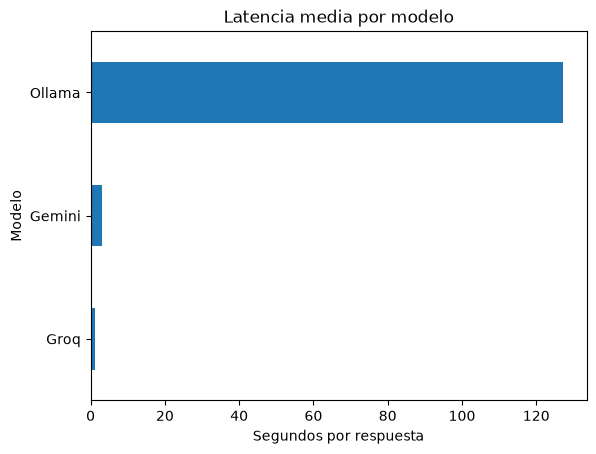

In [5]:
#------gráfico de latencia
import matplotlib.pyplot as plt


resumen["latencia_media_s"].sort_values().plot(kind="barh")
plt.title("Latencia media por modelo")
plt.xlabel("Segundos por respuesta")
plt.ylabel("Modelo")
plt.show()

In [6]:
# -------- mostramos únicamente las preguntas
# -------- donde el modelo no tuvo el comportamiento esperado

errores = df_eval[
    df_eval["abstencion_correcta"] == False
][
    [
        "modelo",
        "id",
        "categoria",
        "respuesta",
        "fuentes"
    ]
]

errores

,modelo,id,categoria,respuesta,fuentes
9,Groq,10,medical_advice,Los medicamentos antidiabéticos que aparecen e...,"[glipimet forte 5 mg/500 mg tablet, glumin 5 m..."
